# EEdit Colab Baseline

This notebook runs a minimal `EEdit` prompt-guided baseline on Google Colab.

Notes:
- `EEdit` depends on `FLUX.1-dev`, so use a Colab GPU runtime.
- The install cell pins `numpy` and related packages to avoid the binary mismatch error you hit.
- After the install cell, restart the runtime once, then continue from the version-check cell.

In [1]:
!nvidia-smi || true

!git clone https://github.com/yuriYanZeXuan/EEdit.git /content/EEdit || true
%cd /content/EEdit
!git fetch --all
!git checkout 35e95e3

%pip uninstall -y numpy opencv-python opencv-python-headless || true
%pip install -q --upgrade pip
%pip install -q --upgrade --force-reinstall --no-cache-dir \
  numpy==1.26.4 \
  torch==2.5.1 torchvision==0.20.1 xformers==0.0.28.post3 \
  diffusers==0.31.0 transformers==4.46.1 accelerate==1.1.0 \
  sentencepiece==0.2.0 safetensors==0.5.2 huggingface_hub==0.26.2 \
  ftfy==6.3.1 einops==0.8.1 omegaconf==2.3.0 \
  pillow==11.1.0 opencv-python-headless==4.10.0.84 gdown

print("Install complete. Restart the runtime now, then continue with the next cell.")

Tue May 26 18:33:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             51W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
import numpy, torch, transformers, gdown

print("numpy:", numpy.__version__)
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("gdown:", gdown.__version__)

if numpy.__version__ != "1.26.4":
    raise RuntimeError("Expected numpy==1.26.4. Rerun the install cell and restart the runtime.")

if not torch.cuda.is_available():
    raise RuntimeError("No CUDA GPU detected. In Colab, switch to Runtime > Change runtime type > GPU.")

major, minor = torch.cuda.get_device_capability()
DEVICE = "cuda"
DTYPE = torch.bfloat16 if major >= 8 else torch.float16

print("GPU:", torch.cuda.get_device_name(0))
print("Capability:", (major, minor))
print("Using dtype:", DTYPE)

numpy: 1.26.4
torch: 2.5.1+cu124
transformers: 4.46.1
gdown: 6.0.0
GPU: NVIDIA A100-SXM4-80GB
Capability: (8, 0)
Using dtype: torch.bfloat16


## Hugging Face Weights

Before the next cell, accept access to `black-forest-labs/FLUX.1-dev`:

- https://huggingface.co/black-forest-labs/FLUX.1-dev

In [2]:
from huggingface_hub import login, snapshot_download
from getpass import getpass
import os

token = getpass("Hugging Face token: ")
login(token=token)

os.makedirs("/content/EEdit/weights", exist_ok=True)

snapshot_download(
    repo_id="black-forest-labs/FLUX.1-dev",
    local_dir="/content/EEdit/weights",
    allow_patterns=[
        "flux1-dev.safetensors",
        "transformer_config.json",
        "model_index.json",
        "scheduler/*",
        "text_encoder/*",
        "text_encoder_2/*",
        "tokenizer/*",
        "tokenizer_2/*",
        "vae/*"
    ]
)

print("Weights downloaded to /content/EEdit/weights")

Hugging Face token: ··········


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.53G [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/168M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/820 [00:00<?, ?B/s]

Weights downloaded to /content/EEdit/weights


## Optional PIE-Bench Dataset

If you want to use the benchmark sample instead of manually uploaded files, run the next cell. If Google Drive quota blocks `mapping_file.json`, skip to the upload cell later and use your own image and mask.

In [3]:
%cd /content
!mkdir -p /content/EEdit/input/inpaint
!gdown --folder "https://drive.google.com/drive/folders/1fU40LzCZWXpI-QBzqX1bY81vADD6G2Jf" -O /content/EEdit/input/inpaint || true
!find /content/EEdit/input/inpaint -maxdepth 2 -type f | sed -n '1,120p'

/content
Retrieving folder contents
Retrieving folder 1ndZl43fueq-81M1YE7ZzDJx2W-dR0Gw2 annotation_images
Retrieving folder 17_FmpP-a4CRkBwaGE5o110XFgOsGHMhR 0_random_140
Processing file 1MV_sjdZVEv2XrAkHFAtuYG3Ke0C8WnGy 000000000000.jpg
Processing file 17ukgyN0l-GAnFeXI4a9sh4-yQujhro8R 000000000001.jpg
Processing file 1dlPUHIOnjCEgQK8-_WwZCVdV8ckdPnJ5 000000000002.jpg
Processing file 1B4RUmpWLnXwxlWvil6eyOM7oxmdeT5zV 000000000003.jpg
Processing file 1UkgJI6k7tvVK11p4wc9mB9Oz8Qa7gMRI 000000000004.jpg
Processing file 11jpGVUgY_dwVrV044lJMA8AD06krVi2F 000000000005.jpg
Processing file 159lcOCHZmLmtNO3zVByzIaP2HT6XEVcU 000000000006.jpg
Processing file 1zF3iVIUF2Wk5ugDVMy4NH9ZZwf3MAwDv 000000000007.jpg
Processing file 17hIcUMayBxZraJajKYnqVCzDcTrQPNRP 000000000008.jpg
Processing file 1arjwJV3JmRwZdwWL3xKXefhh3VXkdN9z 000000000009.jpg
Processing file 1Ke1g1pgIOGqFRWtuWr7H5MfcyAihjz1l 000000000010.jpg
Processing file 1p97rdVXc2e5F1DQKDxroUiQtJZBAWDBP 000000000011.jpg
Processing file 1xXAymtfv

In [4]:
%cd /content/EEdit/input/inpaint
!test -f mapping_file.json && echo "mapping_file.json already exists" || echo "mapping_file.json missing"
!test -f mapping_file.json || echo "If Drive quota blocks the file, upload mapping_file.json manually in the next optional cell."

/content/EEdit/input/inpaint
mapping_file.json missing
If Drive quota blocks the file, upload mapping_file.json manually in the next optional cell.


In [5]:
from google.colab import files
uploaded = files.upload()

if "mapping_file.json" in uploaded:
    !mv mapping_file.json /content/EEdit/input/inpaint/mapping_file.json
    print("Moved mapping_file.json into /content/EEdit/input/inpaint/")
else:
    print("No mapping_file.json uploaded. This is fine if you will use manual image+mask upload instead.")

Saving mapping_file.json to mapping_file.json
mv: 'mapping_file.json' and '/content/EEdit/input/inpaint/mapping_file.json' are the same file
Moved mapping_file.json into /content/EEdit/input/inpaint/


In [6]:
%cd /content/EEdit
!test -f /content/EEdit/input/inpaint/mapping_file.json && python MyCodes/myutils.py || echo "Skipping mask generation because mapping_file.json is not present."

/content/EEdit


In [7]:
import os

PIE_IMAGE_PATH = "/content/EEdit/input/inpaint/annotation_images/0_random_140/000000000000.jpg"
PIE_MASK_PATH = "/content/EEdit/input/inpaint/masks/mask-000.png"
COLAB_INPUT_DIR = "/content/EEdit/colab_inputs"

PROMPT = "a slanted rusty mountain bicycle on the road in front of a building"
OUTPUT_PATH = "/content/EEdit/colab_inputs/eedit_result.png"

if os.path.exists(PIE_IMAGE_PATH) and os.path.exists(PIE_MASK_PATH):
    IMAGE_PATH = PIE_IMAGE_PATH
    MASK_PATH = PIE_MASK_PATH
    print("Using PIE-Bench sample")
else:
    uploaded_files = sorted(
        [f for f in os.listdir(COLAB_INPUT_DIR) if os.path.isfile(os.path.join(COLAB_INPUT_DIR, f)) and f != "eedit_result.png"]
    ) if os.path.exists(COLAB_INPUT_DIR) else []
    if len(uploaded_files) < 2:
        raise RuntimeError("Need either PIE-Bench sample files or two uploaded files: one image and one mask.")
    IMAGE_PATH = os.path.join(COLAB_INPUT_DIR, uploaded_files[0])
    MASK_PATH = os.path.join(COLAB_INPUT_DIR, uploaded_files[1])
    print("Using manually uploaded files")

print("IMAGE_PATH:", IMAGE_PATH)
print("MASK_PATH:", MASK_PATH)


Using PIE-Bench sample
IMAGE_PATH: /content/EEdit/input/inpaint/annotation_images/0_random_140/000000000000.jpg
MASK_PATH: /content/EEdit/input/inpaint/masks/mask-000.png


In [9]:
def load_models(weights_dir, use_predefine=True, device="cuda", dtype=torch.float16):
    if use_predefine:
        from MyCodes.FluxTransformer2DModel_PREDEFINE import FluxTransformer2DModel
    else:
        from MyCodes.FluxTransformer2DModel import FluxTransformer2DModel

    transformer_config_dir = os.path.join(weights_dir, "transformer_config_dir")
    os.makedirs(transformer_config_dir, exist_ok=True)
    transformer_config_dst = os.path.join(transformer_config_dir, "config.json")
    transformer_config_candidates = [
        os.path.join(weights_dir, "transformer", "config.json"),
        os.path.join(weights_dir, "transformer_config.json"),
    ]
    transformer_config_src = next((p for p in transformer_config_candidates if os.path.exists(p)), None)
    if transformer_config_src is None:
        raise FileNotFoundError(
            "Could not find a transformer config. Checked: " + ", ".join(transformer_config_candidates)
        )
    if not os.path.exists(transformer_config_dst):
        with open(transformer_config_src, "r") as src, open(transformer_config_dst, "w") as dst:
            dst.write(src.read())

    transformer = FluxTransformer2DModel.from_single_file(
        pretrained_model_link_or_path_or_dict=f"{weights_dir}/flux1-dev.safetensors",
        config=transformer_config_dir,
        torch_dtype=dtype,
        local_files_only=True,
    )

    text_encoder_2 = T5EncoderModel.from_pretrained(
        weights_dir,
        subfolder="text_encoder_2",
        torch_dtype=dtype,
    )

    pipe = FluxInpaintPipeline.from_pretrained(
        weights_dir,
        transformer=None,
        text_encoder_2=None,
        torch_dtype=dtype,
    )

    pipe.transformer = transformer
    pipe.text_encoder_2 = text_encoder_2
    pipe.transformer.forward = types.MethodType(MyFluxForward.forward, pipe.transformer)
    pipe.to(device)
    return pipe

In [11]:
!find /content/EEdit/weights -maxdepth 3 | sed -n '1,200p'

/content/EEdit/weights
/content/EEdit/weights/scheduler
/content/EEdit/weights/scheduler/scheduler_config.json
/content/EEdit/weights/.gitkeep
/content/EEdit/weights/.cache
/content/EEdit/weights/.cache/huggingface
/content/EEdit/weights/.cache/huggingface/.gitignore
/content/EEdit/weights/.cache/huggingface/download
/content/EEdit/weights/text_encoder_2
/content/EEdit/weights/text_encoder_2/model-00001-of-00002.safetensors
/content/EEdit/weights/text_encoder_2/model.safetensors.index.json
/content/EEdit/weights/text_encoder_2/model-00002-of-00002.safetensors
/content/EEdit/weights/text_encoder_2/config.json
/content/EEdit/weights/model_index.json
/content/EEdit/weights/flux1-dev.safetensors
/content/EEdit/weights/vae
/content/EEdit/weights/vae/diffusion_pytorch_model.safetensors
/content/EEdit/weights/vae/config.json
/content/EEdit/weights/tokenizer_2
/content/EEdit/weights/tokenizer_2/tokenizer_config.json
/content/EEdit/weights/tokenizer_2/spiece.model
/content/EEdit/weights/tokeniz

In [13]:
import os
import sys
import types
from pathlib import Path

import torch
from diffusers.utils import load_image
from transformers import T5EncoderModel
from huggingface_hub import snapshot_download

sys.path.append("/content/EEdit")

from cache_functions import cache_init, convert_to_cache_index, edit_mask_parser, predefine_cache_fresh_indices
from MyCodes.MyFluxInpaintPipeline import FluxInpaintPipeline
from MyCodes import MyFluxForward

snapshot_download(
    repo_id="black-forest-labs/FLUX.1-dev",
    local_dir="/content/EEdit/weights",
    allow_patterns=["transformer/config.json"],
)

PARAM = {
    "use_cache": True,
    "num_inference_steps": 28,
    "cascade_num": 3,
    "fresh_ratio": 0.1,
    "fresh_threshold": 3,
    "soft_fresh_weight": 0.25,
    "tailing_step": 1,
    "strength": 1.0,
    "inv_skip": 3,
    "eta": 0.7,
    "gamma": 0.7,
    "stop_timestep": 6,
    "mask_timestep": 18,
    "cache_type": "ours_predefine",
}

if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required.")

major, minor = torch.cuda.get_device_capability()
DEVICE = "cuda"
DTYPE = torch.bfloat16 if major >= 8 else torch.float16

def load_models(weights_dir, use_predefine=True, device="cuda", dtype=torch.float16):
    if use_predefine:
        from MyCodes.FluxTransformer2DModel_PREDEFINE import FluxTransformer2DModel
    else:
        from MyCodes.FluxTransformer2DModel import FluxTransformer2DModel

    transformer_config_dir = os.path.join(weights_dir, "transformer_config_dir")
    os.makedirs(transformer_config_dir, exist_ok=True)
    transformer_config_dst = os.path.join(transformer_config_dir, "config.json")
    transformer_config_candidates = [
        os.path.join(weights_dir, "transformer", "config.json"),
        os.path.join(weights_dir, "transformer_config.json"),
    ]
    transformer_config_src = next((p for p in transformer_config_candidates if os.path.exists(p)), None)
    if transformer_config_src is None:
        raise FileNotFoundError(
            "Could not find a transformer config. Checked: " + ", ".join(transformer_config_candidates)
        )
    with open(transformer_config_src, "r") as src, open(transformer_config_dst, "w") as dst:
        dst.write(src.read())

    transformer = FluxTransformer2DModel.from_single_file(
        pretrained_model_link_or_path_or_dict=f"{weights_dir}/flux1-dev.safetensors",
        config=transformer_config_dir,
        torch_dtype=dtype,
        local_files_only=True,
    )

    text_encoder_2 = T5EncoderModel.from_pretrained(
        weights_dir,
        subfolder="text_encoder_2",
        torch_dtype=dtype,
    )

    pipe = FluxInpaintPipeline.from_pretrained(
        weights_dir,
        transformer=None,
        text_encoder_2=None,
        torch_dtype=dtype,
    )

    pipe.transformer = transformer
    pipe.text_encoder_2 = text_encoder_2
    pipe.transformer.forward = types.MethodType(MyFluxForward.forward, pipe.transformer)
    pipe.to(device)
    return pipe

pipe = load_models(
    weights_dir="/content/EEdit/weights",
    use_predefine=True,
    device=DEVICE,
    dtype=DTYPE,
)

main_image = load_image(IMAGE_PATH)
mask_image = load_image(MASK_PATH)
height = main_image.height
width = main_image.width

model_kwargs = {
    "fresh_ratio": PARAM["fresh_ratio"],
    "cache_type": PARAM["cache_type"],
    "ratio_scheduler": "constant",
    "force_fresh": "global",
    "fresh_threshold": PARAM["fresh_threshold"],
    "soft_fresh_weight": PARAM["soft_fresh_weight"],
    "tailing_step": PARAM["tailing_step"],
    "hw": (height // 16, width // 16),
}

edit_idx = edit_mask_parser(
    mask_image,
    height=height,
    width=width,
    cascade_num=PARAM["cascade_num"],
)
cache_dic, current = cache_init(model_kwargs, PARAM["num_inference_steps"], edit_idx)
current["edit_idx_merged"] = convert_to_cache_index(
    edit_idx,
    edit_base=2,
    bonus_ratio=0.8,
    height=height,
    width=width,
).to(DEVICE)
predefine_cache_fresh_indices(cache_dic, current)

joint_attention_kwargs = {
    "use_attn_map": False,
    "cache_dic": cache_dic,
    "use_cache": PARAM["use_cache"],
    "current": current,
}

generator = torch.Generator(device=DEVICE).manual_seed(42)
torch.manual_seed(42)

result = pipe.gen(
    prompt=PROMPT,
    image=main_image,
    mask_image=mask_image,
    num_inference_steps=PARAM["num_inference_steps"],
    strength=PARAM["strength"],
    height=height,
    width=width,
    joint_attention_kwargs=joint_attention_kwargs,
    generator=generator,
    eta=PARAM["eta"],
    gamma=PARAM["gamma"],
    skip_T=PARAM["inv_skip"],
    skip_T_fwd=1,
    stop_timestep=PARAM["stop_timestep"],
    mask_timestep=PARAM["mask_timestep"],
)

image = result.images[0]
Path(os.path.dirname(OUTPUT_PATH)).mkdir(parents=True, exist_ok=True)
image.save(OUTPUT_PATH)
print("Saved:", OUTPUT_PATH)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

init with MyFluxAttnProcessor2_0


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

Saved: /content/EEdit/colab_inputs/eedit_result.png


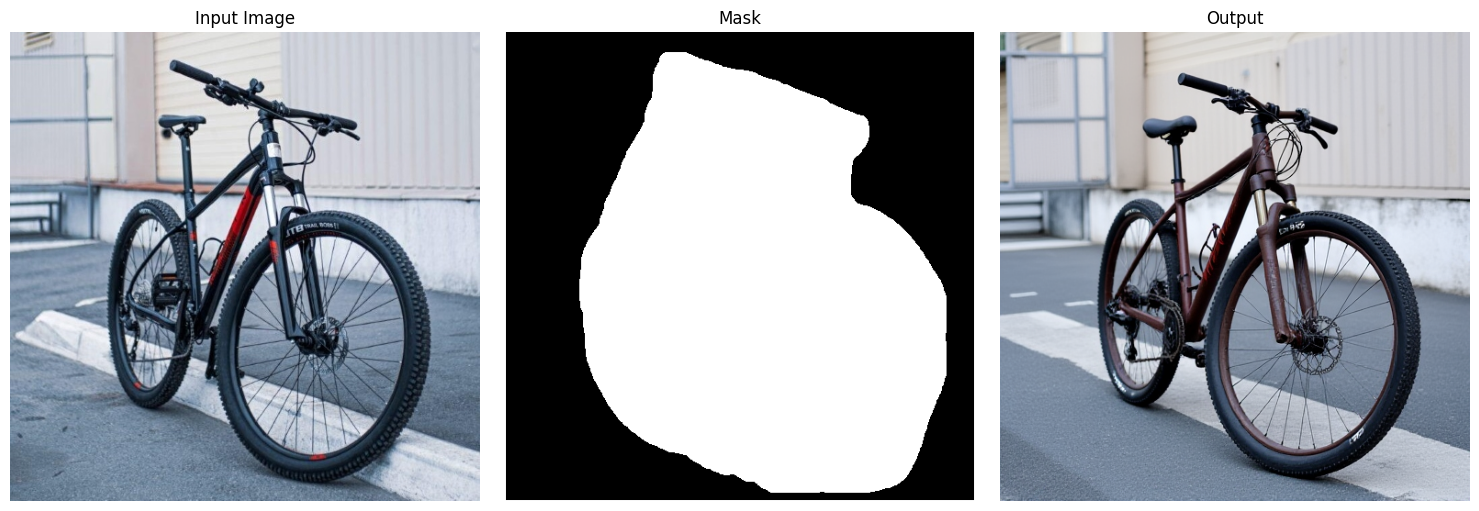

In [14]:
from PIL import Image
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

img = Image.open(IMAGE_PATH)
mask = Image.open(MASK_PATH)

axes[0].imshow(img)
axes[0].set_title("Input Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")

if os.path.exists(OUTPUT_PATH):
    out = Image.open(OUTPUT_PATH)
    axes[2].imshow(out)
    axes[2].set_title("Output")
else:
    axes[2].text(0.5, 0.5, "Output not found", ha="center", va="center")
    axes[2].set_title("Output")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [15]:
from pathlib import Path

p = Path("/content/EEdit/composition_gen.py")
text = p.read_text()

old = """def load_models(args, dtype=torch.bfloat16):
    if args.use_predefine:
        from MyCodes.FluxTransformer2DModel_PREDEFINE import FluxTransformer2DModel
    else:
        from MyCodes.FluxTransformer2DModel import FluxTransformer2DModel
    transformer = FluxTransformer2DModel.from_single_file(
        pretrained_model_link_or_path_or_dict=f"{args.weights_dir}/flux1-dev.safetensors",
        config=f"{args.weights_dir}/transformer_config.json",
        torch_dtype=dtype,
        local_files_only=True)
"""
new = """def load_models(args, dtype=torch.bfloat16):
    if args.use_predefine:
        from MyCodes.FluxTransformer2DModel_PREDEFINE import FluxTransformer2DModel
    else:
        from MyCodes.FluxTransformer2DModel import FluxTransformer2DModel

    transformer_config_dir = os.path.join(args.weights_dir, "transformer_config_dir")
    os.makedirs(transformer_config_dir, exist_ok=True)
    transformer_config_dst = os.path.join(transformer_config_dir, "config.json")
    transformer_config_candidates = [
        os.path.join(args.weights_dir, "transformer", "config.json"),
        os.path.join(args.weights_dir, "transformer_config.json"),
    ]
    transformer_config_src = next((x for x in transformer_config_candidates if os.path.exists(x)), None)
    if transformer_config_src is None:
        raise FileNotFoundError(
            "Could not find transformer config. Checked: " + ", ".join(transformer_config_candidates)
        )
    with open(transformer_config_src, "r") as src, open(transformer_config_dst, "w") as dst:
        dst.write(src.read())

    transformer = FluxTransformer2DModel.from_single_file(
        pretrained_model_link_or_path_or_dict=f"{args.weights_dir}/flux1-dev.safetensors",
        config=transformer_config_dir,
        torch_dtype=dtype,
        local_files_only=True)
"""

if old not in text:
    raise RuntimeError("Expected block not found in composition_gen.py")

p.write_text(text.replace(old, new))
print("Patched", p)

Patched /content/EEdit/composition_gen.py


In [16]:
%%writefile /content/EEdit/configs/composition/one_comp.json
{
  "imgs": [
    {
      "prompt": "a cartoon animation of a sheep in the forest",
      "main_image": "/content/EEdit/input/composition/Real-Cartoon/0000 a cartoon animation of a sheep in the forest/bg58.png",
      "ref_image": "/content/EEdit/input/composition/Real-Cartoon/0000 a cartoon animation of a sheep in the forest/fg35_63d22cda1f5b66e8e5aca776.jpg",
      "ref_segment": "/content/EEdit/input/composition/Real-Cartoon/0000 a cartoon animation of a sheep in the forest/fg35_mask.png",
      "x1": 152,
      "y1": 296,
      "x2": 359,
      "y2": 471
    }
  ]
}

Writing /content/EEdit/configs/composition/one_comp.json


In [17]:
!find /content/EEdit/input -maxdepth 3 | sed -n '1,200p'

/content/EEdit/input
/content/EEdit/input/.gitkeep
/content/EEdit/input/inpaint
/content/EEdit/input/inpaint/mapping_file.json
/content/EEdit/input/inpaint/masks
/content/EEdit/input/inpaint/masks/mask-219.png
/content/EEdit/input/inpaint/masks/mask-074.png
/content/EEdit/input/inpaint/masks/mask-095.png
/content/EEdit/input/inpaint/masks/mask-349.png
/content/EEdit/input/inpaint/masks/mask-507.png
/content/EEdit/input/inpaint/masks/mask-393.png
/content/EEdit/input/inpaint/masks/mask-064.png
/content/EEdit/input/inpaint/masks/mask-204.png
/content/EEdit/input/inpaint/masks/mask-174.png
/content/EEdit/input/inpaint/masks/mask-189.png
/content/EEdit/input/inpaint/masks/mask-357.png
/content/EEdit/input/inpaint/masks/mask-141.png
/content/EEdit/input/inpaint/masks/mask-196.png
/content/EEdit/input/inpaint/masks/mask-203.png
/content/EEdit/input/inpaint/masks/mask-441.png
/content/EEdit/input/inpaint/masks/mask-588.png
/content/EEdit/input/inpaint/masks/mask-429.png
/content/EEdit/input/i

In [18]:
%cd /content
!git clone https://github.com/Shilin-LU/TF-ICON.git

/content
Cloning into 'TF-ICON'...
remote: Enumerating objects: 418, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 418 (delta 23), reused 29 (delta 22), pack-reused 375 (from 1)
Receiving objects: 100% (418/418), 76.89 MiB | 14.56 MiB/s, done.
Resolving deltas: 100% (172/172), done.


In [19]:
!mkdir -p /content/EEdit/input/composition/Real-Cartoon

In [20]:
!find /content/TF-ICON/inputs -maxdepth 3 | sed -n '1,200p'

/content/TF-ICON/inputs
/content/TF-ICON/inputs/same_domain
/content/TF-ICON/inputs/same_domain/a professional photograph of an eiffel tower in the distance, ultra realistic
/content/TF-ICON/inputs/same_domain/a professional photograph of an eiffel tower in the distance, ultra realistic/bg36.png
/content/TF-ICON/inputs/same_domain/a professional photograph of an eiffel tower in the distance, ultra realistic/mask_bg_fg.jpg
/content/TF-ICON/inputs/same_domain/a professional photograph of an eiffel tower in the distance, ultra realistic/cp_bg_fg.jpg
/content/TF-ICON/inputs/same_domain/a professional photograph of an eiffel tower in the distance, ultra realistic/fg82_mask.png
/content/TF-ICON/inputs/same_domain/a professional photograph of an eiffel tower in the distance, ultra realistic/fg82.jpg
/content/TF-ICON/inputs/same_domain/a professional photograph of an eiffel tower in the distance, ultra realistic/dccf_image.jpg
/content/TF-ICON/inputs/same_domain/a professional photograph of a 

In [25]:
import os
import re
import json
import shutil
from pathlib import Path
from PIL import Image
import numpy as np

tf_root = Path("/content/TF-ICON/inputs/cross_domain")
eedit_root = Path("/content/EEdit/input/composition")
cfg_root = Path("/content/EEdit/configs/composition")

eedit_root.mkdir(parents=True, exist_ok=True)
cfg_root.mkdir(parents=True, exist_ok=True)

groups = {
    "Real-Cartoon": [],
    "Real-Painting": [],
    "Real-Sketch": [],
    "Real-Real": [],
}

def slug(i, prompt):
    return f"{i:04d} {prompt}"

def detect_group(prompt):
    p = prompt.lower()
    if "cartoon" in p:
        return "Real-Cartoon"
    if "oil painting" in p or "van gogh" in p or "painting" in p:
        return "Real-Painting"
    if "pencil drawing" in p or "sketch" in p or "black and white" in p:
        return "Real-Sketch"
    return "Real-Real"

def pick_ref_image(files):
    names = [f.name for f in files]
    # best case: actual fg image
    fg_candidates = [
        f for f in files
        if re.match(r"^fg.*\.(jpg|jpeg|png)$", f.name.lower())
        and "_mask" not in f.name.lower()
    ]
    if fg_candidates:
        return fg_candidates[0]
    # fallback if dataset only exposes dccf_image
    for f in files:
        if f.name.lower() == "dccf_image.jpg":
            return f
    raise RuntimeError(f"Could not find reference image in {[f.name for f in files]}")

def pick_bg_image(files):
    for f in files:
        if re.match(r"^bg.*\.(jpg|jpeg|png)$", f.name.lower()):
            return f
    raise RuntimeError(f"Could not find background image in {[f.name for f in files]}")

def pick_fg_mask(files):
    for f in files:
        n = f.name.lower()
        if n.startswith("fg") and "_mask" in n and n.endswith((".png", ".jpg", ".jpeg")):
            return f
    raise RuntimeError(f"Could not find foreground mask in {[f.name for f in files]}")

def pick_place_mask(files):
    for f in files:
        if f.name.lower() == "mask_bg_fg.jpg" or f.name.lower() == "mask_bg_fg.png":
            return f
    raise RuntimeError(f"Could not find placement mask in {[f.name for f in files]}")

sample_dirs = [p for p in tf_root.iterdir() if p.is_dir()]
sample_dirs = sorted(sample_dirs, key=lambda p: p.name.lower())

for idx, sample_dir in enumerate(sample_dirs):
    prompt = sample_dir.name
    group = detect_group(prompt)
    out_dir = eedit_root / group / slug(idx, prompt)
    out_dir.mkdir(parents=True, exist_ok=True)

    files = [p for p in sample_dir.iterdir() if p.is_file()]
    bg = pick_bg_image(files)
    ref = pick_ref_image(files)
    ref_mask = pick_fg_mask(files)
    place_mask = pick_place_mask(files)

    shutil.copy2(bg, out_dir / bg.name)
    shutil.copy2(ref, out_dir / ref.name)
    shutil.copy2(ref_mask, out_dir / ref_mask.name)
    shutil.copy2(place_mask, out_dir / place_mask.name)

    arr = np.array(Image.open(place_mask).convert("L"))
    ys, xs = np.where(arr > 10)
    x1, x2 = int(xs.min()), int(xs.max())
    y1, y2 = int(ys.min()), int(ys.max())

    groups[group].append({
        "prompt": prompt,
        "main_image": str(out_dir / bg.name),
        "ref_image": str(out_dir / ref.name),
        "ref_segment": str(out_dir / ref_mask.name),
        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2,
    })

for group, imgs in groups.items():
    out_json = cfg_root / f"{group}.auto.json"
    with open(out_json, "w") as f:
        json.dump({"imgs": imgs}, f, indent=2)

for group, imgs in groups.items():
    print(group, len(imgs))

Real-Cartoon 1
Real-Painting 2
Real-Sketch 1
Real-Real 0


In [30]:
import gc
import torch

gc.collect()

for obj in gc.get_objects():
    try:
        if torch.is_tensor(obj) or (hasattr(obj, "data") and torch.is_tensor(obj.data)):
            del obj
    except:
        pass

torch.cuda.empty_cache()
torch.cuda.ipc_collect()

!nvidia-smi

/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1021: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)
/tmp/ipykernel_4030/2983395882.py:8: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if torch.is_tensor(obj) or (hasattr(obj, "data") and torch.is_tensor(obj.data)):


Tue May 26 19:03:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   32C    P0             61W /  400W |   35482MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [31]:
%cd /content/EEdit

!python composition_gen.py \
  --weights_dir /content/EEdit/weights \
  --config_path /content/EEdit/configs/composition/RC_config.json \
  --img_config /content/EEdit/configs/composition/Real-Cartoon.auto.json \
  --output_dir /content/EEdit/EEdit_outputs/comp/Real-Cartoon \
  --use_predefine 1

/content/EEdit
init with MyFluxAttnProcessor2_0
Loading checkpoint shards: 100% 2/2 [00:00<00:00,  2.72it/s]
Loading pipeline components...:  60% 3/5 [00:00<00:00,  5.89it/s]You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
Loading pipeline components...: 100% 5/5 [00:00<00:00,  6.13it/s]
100% 28/28 [00:02<00:00, 13.72it/s]


In [32]:
%cd /content/EEdit

!python composition_gen.py \
  --weights_dir /content/EEdit/weights \
  --config_path /content/EEdit/configs/composition/RP_config.json \
  --img_config /content/EEdit/configs/composition/Real-Painting.auto.json \
  --output_dir /content/EEdit/EEdit_outputs/comp/Real-Painting \
  --use_predefine 1

/content/EEdit
init with MyFluxAttnProcessor2_0
Loading checkpoint shards: 100% 2/2 [00:00<00:00,  2.79it/s]
Loading pipeline components...:   0% 0/5 [00:00<?, ?it/s]You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
Loading pipeline components...: 100% 5/5 [00:00<00:00,  6.32it/s]
100% 28/28 [00:02<00:00, 13.69it/s]
100% 28/28 [00:02<00:00, 13.68it/s]


In [33]:
%cd /content/EEdit

!python composition_gen.py \
  --weights_dir /content/EEdit/weights \
  --config_path /content/EEdit/configs/composition/RS_config.json \
  --img_config /content/EEdit/configs/composition/Real-Sketch.auto.json \
  --output_dir /content/EEdit/EEdit_outputs/comp/Real-Sketch \
  --use_predefine 1

/content/EEdit
init with MyFluxAttnProcessor2_0
Loading checkpoint shards: 100% 2/2 [00:00<00:00,  2.83it/s]
Loading pipeline components...:   0% 0/5 [00:00<?, ?it/s]You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
Loading pipeline components...: 100% 5/5 [00:00<00:00,  6.32it/s]
100% 28/28 [00:02<00:00, 13.78it/s]


In [34]:
import json

paths = [
    "/content/EEdit/configs/composition/Real-Cartoon.auto.json",
    "/content/EEdit/configs/composition/Real-Painting.auto.json",
    "/content/EEdit/configs/composition/Real-Sketch.auto.json",
    "/content/EEdit/configs/composition/Real-Real.auto.json",
]

for p in paths:
    try:
        with open(p) as f:
            data = json.load(f)
        print(p, len(data["imgs"]))
    except Exception as e:
        print(p, "ERROR:", e)

/content/EEdit/configs/composition/Real-Cartoon.auto.json 1
/content/EEdit/configs/composition/Real-Painting.auto.json 2
/content/EEdit/configs/composition/Real-Sketch.auto.json 1
/content/EEdit/configs/composition/Real-Real.auto.json 0


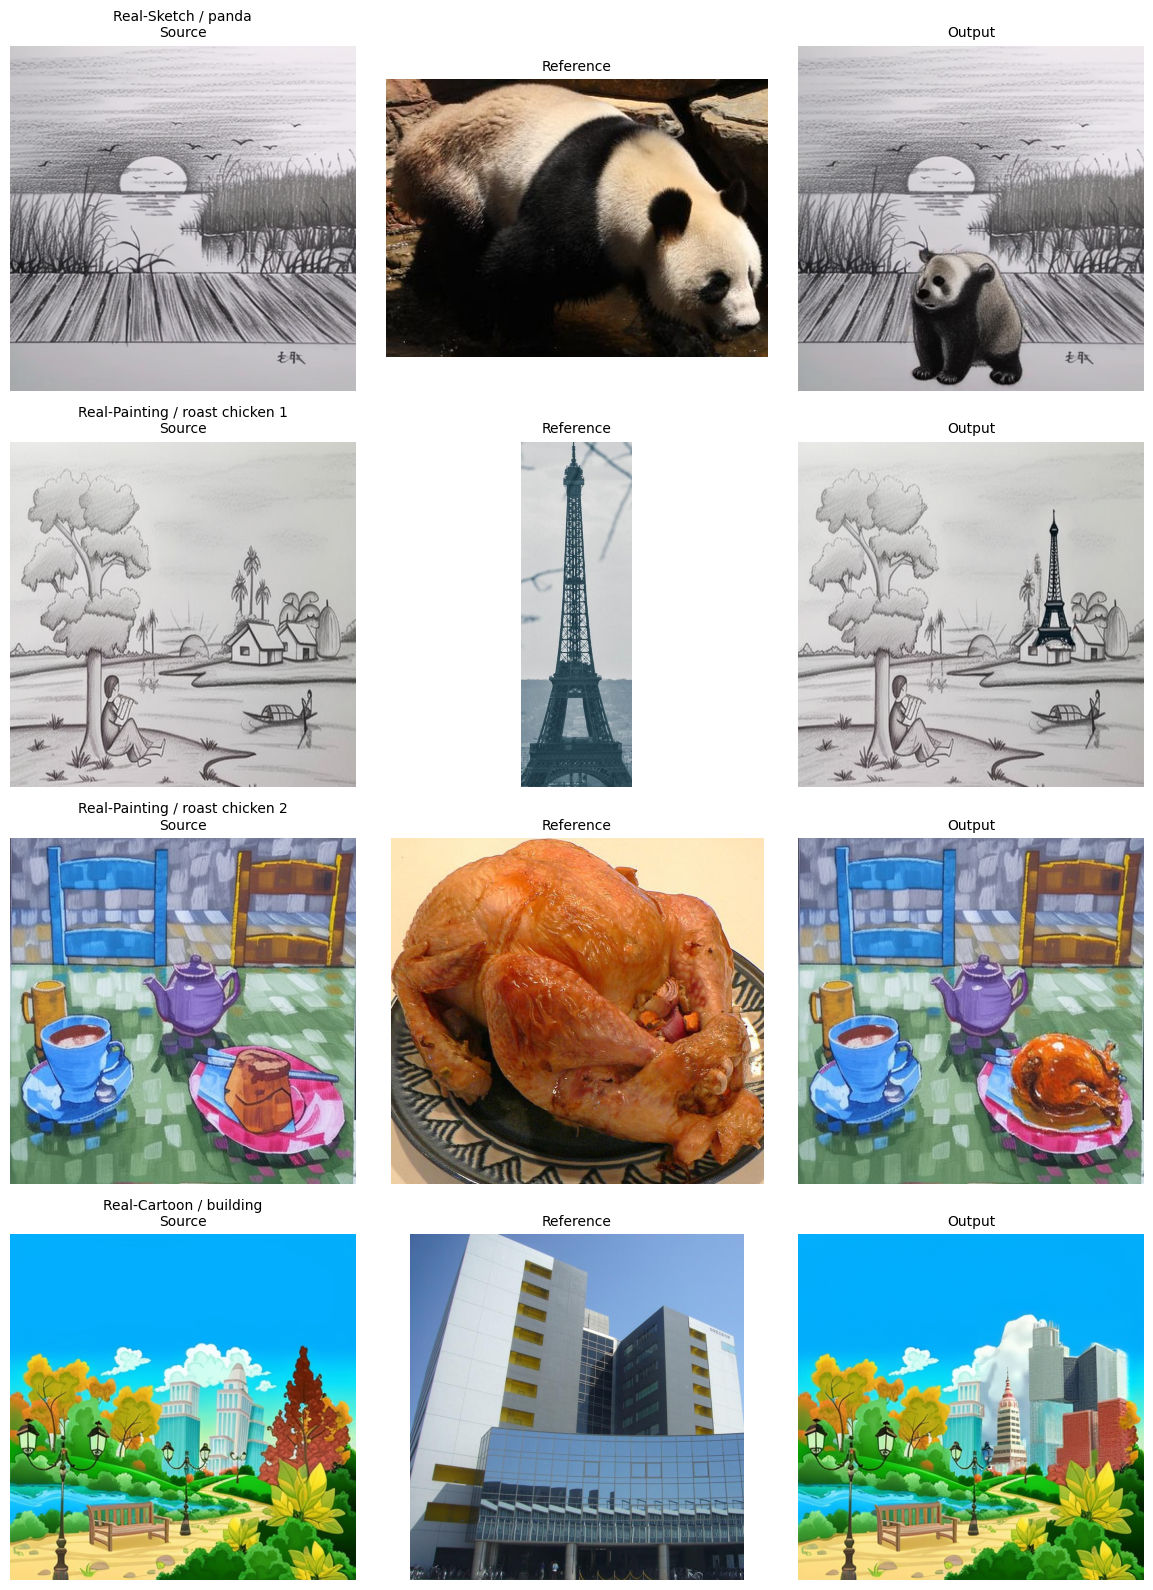

In [37]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Assume 'groups' variable is available from previous cell execution
# (groups = { "Real-Cartoon": [...], "Real-Painting": [...], "Real-Sketch": [...], "Real-Real": [], })

triplets_new = []

# Function to safely get output path based on group name and index
def get_output_path(group_name, output_idx):
    base_dir = "/content/EEdit/EEdit_outputs/comp"
    output_dir = os.path.join(base_dir, group_name)
    # Ensure the directory exists before trying to save, though composition_gen.py should create it
    os.makedirs(output_dir, exist_ok=True)
    return os.path.join(output_dir, f"{output_idx:03d}.png")

# Real-Sketch / panda
if groups.get("Real-Sketch") and len(groups["Real-Sketch"]) > 0:
    panda_data = groups["Real-Sketch"][0]
    triplets_new.append({
        "title": "Real-Sketch / panda",
        "source": panda_data["main_image"],
        "reference": panda_data["ref_image"],
        "output": get_output_path("Real-Sketch", 1), # Assuming 001.png is the first output for Real-Sketch
    })

# Real-Painting / roast chicken
if groups.get("Real-Painting") and len(groups["Real-Painting"]) > 0:
    chicken_data_1 = groups["Real-Painting"][0]
    chicken_data_2 = groups["Real-Painting"][1]
    triplets_new.append({
        "title": "Real-Painting / roast chicken 1",
        "source": chicken_data_1["main_image"],
        "reference": chicken_data_1["ref_image"],
        "output": get_output_path("Real-Painting", 1), # Assuming 001.png
    })
    triplets_new.append({
        "title": "Real-Painting / roast chicken 2",
        "source": chicken_data_2["main_image"],
        "reference": chicken_data_2["ref_image"],
        "output": get_output_path("Real-Painting", 2), # Assuming 002.png
    })

# Real-Cartoon / building
if groups.get("Real-Cartoon") and len(groups["Real-Cartoon"]) > 0:
    building_data = groups["Real-Cartoon"][0]
    triplets_new.append({
        "title": "Real-Cartoon / building",
        "source": building_data["main_image"],
        "reference": building_data["ref_image"],
        "output": get_output_path("Real-Cartoon", 1), # Assuming 001.png
    })

triplets = triplets_new

fig, axes = plt.subplots(len(triplets), 3, figsize=(12, 4 * len(triplets)))

if len(triplets) == 1:
    axes = [axes]

for row, item in enumerate(triplets):
    src_path = item["source"]
    ref_path = item["reference"]
    out_path = item["output"]

    # Check if files exist before trying to open them
    if os.path.exists(src_path):
        src = Image.open(src_path)
    else:
        print(f"Warning: Source image not found: {src_path}")
        src = Image.new("RGB", (100, 100), color="red") # Placeholder

    if os.path.exists(ref_path):
        ref = Image.open(ref_path)
    else:
        print(f"Warning: Reference image not found: {ref_path}")
        ref = Image.new("RGB", (100, 100), color="blue") # Placeholder

    if os.path.exists(out_path):
        out = Image.open(out_path)
    else:
        print(f"Warning: Output image not found: {out_path}")
        out = Image.new("RGB", (100, 100), color="green") # Placeholder

    axes[row][0].imshow(src)
    axes[row][0].set_title(f'{item["title"]}\nSource', fontsize=10)
    axes[row][0].axis("off")

    axes[row][1].imshow(ref)
    axes[row][1].set_title("Reference", fontsize=10)
    axes[row][1].axis("off")

    axes[row][2].imshow(out)
    axes[row][2].set_title("Output", fontsize=10)
    axes[row][2].axis("off")

plt.tight_layout()
plt.show()